In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [189]:
df = pd.read_csv('/content/AB_NYC_2019.csv')

In [190]:
df.shape

(48895, 16)

In [191]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [193]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


In [194]:
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


In [195]:
df =df.drop(['id', 'name', 'host_id', 'host_name', 'last_review'], axis=1)

In [196]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [197]:
df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


In [198]:
df['reviews_per_month'] = df['reviews_per_month'].fillna(df['reviews_per_month'].mean())

In [199]:
df.isnull().sum()

,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0
minimum_nights,0
number_of_reviews,0
reviews_per_month,0
calculated_host_listings_count,0


In [200]:
df.duplicated().sum()

np.int64(0)

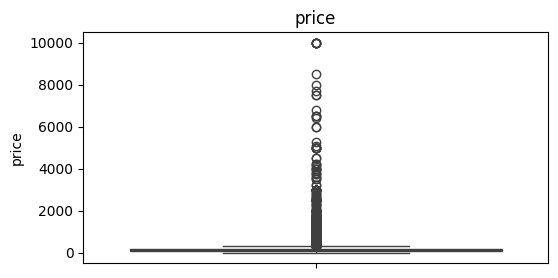

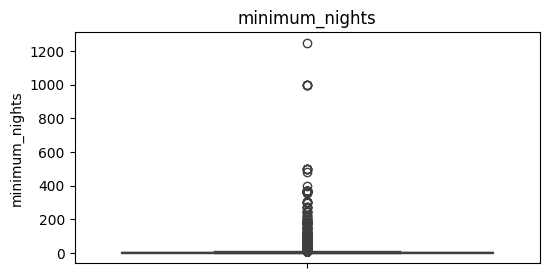

In [201]:
outliers_detection = ['price','minimum_nights']
for col in outliers_detection:
  plt.figure(figsize=(6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [202]:
#Oulier
for col in outliers_detection:
  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)

In [203]:
IQR=Q3-Q1
lower_range=Q1-1.5*IQR
upper_range=Q3+1.5*IQR

In [204]:
df[col]=np.where(df[col]>upper_range,upper_range,df[col])
df[col]=np.where(df[col]<lower_range,lower_range,df[col])

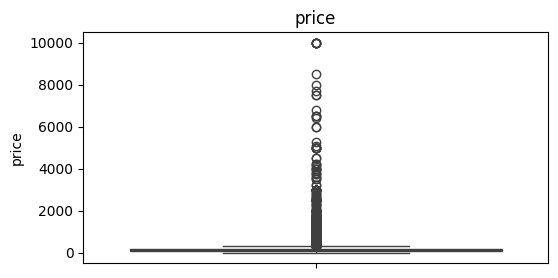

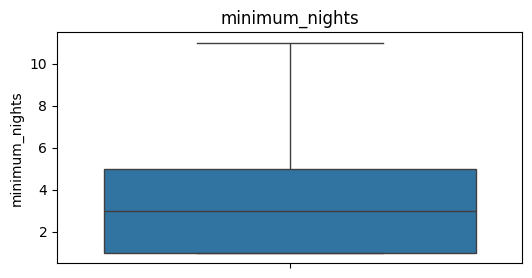

In [205]:
outliers_detection = ['price','minimum_nights']
for col in outliers_detection:
  plt.figure(figsize=(6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [206]:
df = df.drop(['neighbourhood'],axis=1)

In [207]:
num_col=df.select_dtypes(include=['int64','float64']).columns
cat_col=df.select_dtypes(include='object').columns

In [208]:
# 0ne_hot Encoding
df = pd.get_dummies(df, columns=cat_col, drop_first=True)
df

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40.64749,-73.97237,149,1.0,9,0.210000,6,365,True,False,False,False,True,False
1,40.75362,-73.98377,225,1.0,45,0.380000,2,355,False,True,False,False,False,False
2,40.80902,-73.94190,150,3.0,0,1.373221,1,365,False,True,False,False,True,False
3,40.68514,-73.95976,89,1.0,270,4.640000,1,194,True,False,False,False,False,False
4,40.79851,-73.94399,80,10.0,9,0.100000,1,0,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40.67853,-73.94995,70,2.0,0,1.373221,2,9,True,False,False,False,True,False
48891,40.70184,-73.93317,40,4.0,0,1.373221,2,36,True,False,False,False,True,False
48892,40.81475,-73.94867,115,10.0,0,1.373221,1,27,False,True,False,False,False,False
48893,40.75751,-73.99112,55,1.0,0,1.373221,6,2,False,True,False,False,False,True


In [209]:
df = df.astype(int)
df

,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,room_type_Private room,room_type_Shared room
0,40,-73,149,1,9,0,6,365,1,0,0,0,1,0
1,40,-73,225,1,45,0,2,355,0,1,0,0,0,0
2,40,-73,150,3,0,1,1,365,0,1,0,0,1,0
3,40,-73,89,1,270,4,1,194,1,0,0,0,0,0
4,40,-73,80,10,9,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,40,-73,70,2,0,1,2,9,1,0,0,0,1,0
48891,40,-73,40,4,0,1,2,36,1,0,0,0,1,0
48892,40,-73,115,10,0,1,1,27,0,1,0,0,0,0
48893,40,-73,55,1,0,1,6,2,0,1,0,0,0,1


In [210]:
# ML

#step 1
X = df.drop('price', axis=1)
y = df['price']

print(X.head())
print(y.head())

   latitude  longitude  minimum_nights  number_of_reviews  reviews_per_month  \
0        40        -73               1                  9                  0   
1        40        -73               1                 45                  0   
2        40        -73               3                  0                  1   
3        40        -73               1                270                  4   
4        40        -73              10                  9                  0   

   calculated_host_listings_count  availability_365  \
0                               6               365   
1                               2               355   
2                               1               365   
3                               1               194   
4                               1                 0   

   neighbourhood_group_Brooklyn  neighbourhood_group_Manhattan  \
0                             1                              0   
1                             0                         

In [211]:
# Train_ Test _split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X,y,test_size=0.2, random_state = 42)




In [212]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [213]:
# Train the Model
model.fit(X_train,y_train)

LinearRegression()

In [214]:
print(model.coef_)


[ 0.00000000e+00 -4.90691699e+01 -3.07696178e+00 -3.81477243e-01
  9.24670993e-01 -1.36447051e-01  2.04473934e-01  3.57185654e+01
  8.96294568e+01  1.46302951e+01 -4.01642749e+01 -1.11807174e+02
 -1.47470999e+02]


In [215]:
print(model.intercept_)

-3435.8773905932285


In [216]:
y_pred = model.predict(X_test)

In [217]:
# compare Actual vs predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison)

       Actual   Predicted
879        89  187.517231
44383      30   30.863377
15394     120  111.218813
43230     470  288.732726
16332     199  224.201000
...       ...         ...
20477     215  236.548737
44969     100  181.138660
36577      70   44.487369
11477     500  230.435771
1023      125  178.374114

[9779 rows x 2 columns]


In [218]:
 #MSE
from sklearn.metrics import mean_absolute_error,root_mean_squared_error

#Calculate MAE(MAE)
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', mae)

# RMSE#
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', rmse)



Mean Absolute Error: 70.77150690847692
Root Mean Squared Error: 197.19559706076933


R2 Score: 0.12098434896837706


<function matplotlib.pyplot.show(close=None, block=None)>

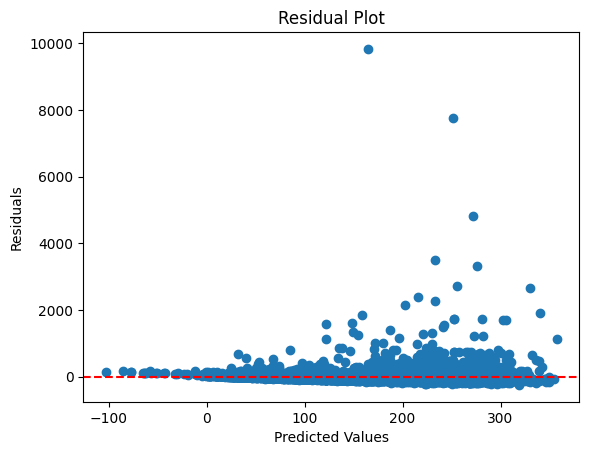

In [219]:
from sklearn.metrics import r2_score
# calculate R2 score

r2 = r2_score(y_test, y_pred)
print('R2 Score:', r2)

# plot residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show

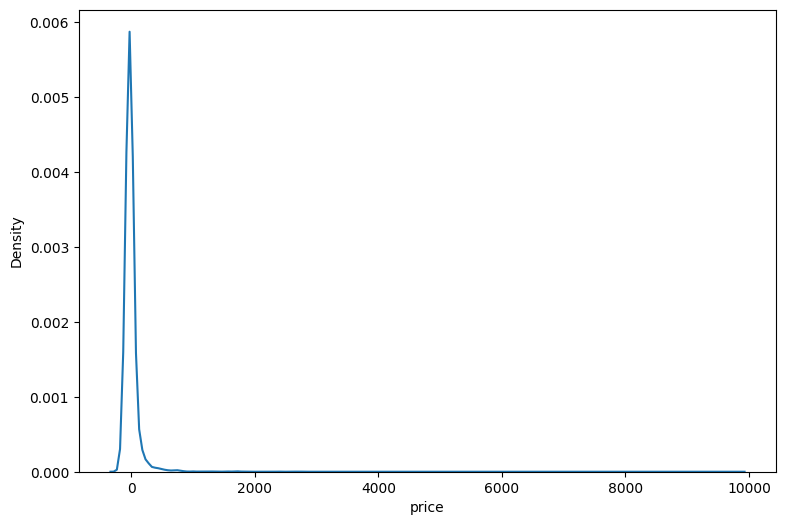

In [220]:
residuals = y_test-y_pred
plt.figure(figsize =(9,6))
sns.kdeplot(residuals)
plt.show()



                              Feature  Coefficient
0                            latitude     0.000000
1                           longitude   -49.069170
2                      minimum_nights    -3.076962
3                   number_of_reviews    -0.381477
4                   reviews_per_month     0.924671
5      calculated_host_listings_count    -0.136447
6                    availability_365     0.204474
7        neighbourhood_group_Brooklyn    35.718565
8       neighbourhood_group_Manhattan    89.629457
9          neighbourhood_group_Queens    14.630295
10  neighbourhood_group_Staten Island   -40.164275
11             room_type_Private room  -111.807174
12              room_type_Shared room  -147.470999
                              Feature  Coefficient
8       neighbourhood_group_Manhattan    89.629457
7        neighbourhood_group_Brooklyn    35.718565
9          neighbourhood_group_Queens    14.630295
4                   reviews_per_month     0.924671
6                    availabili

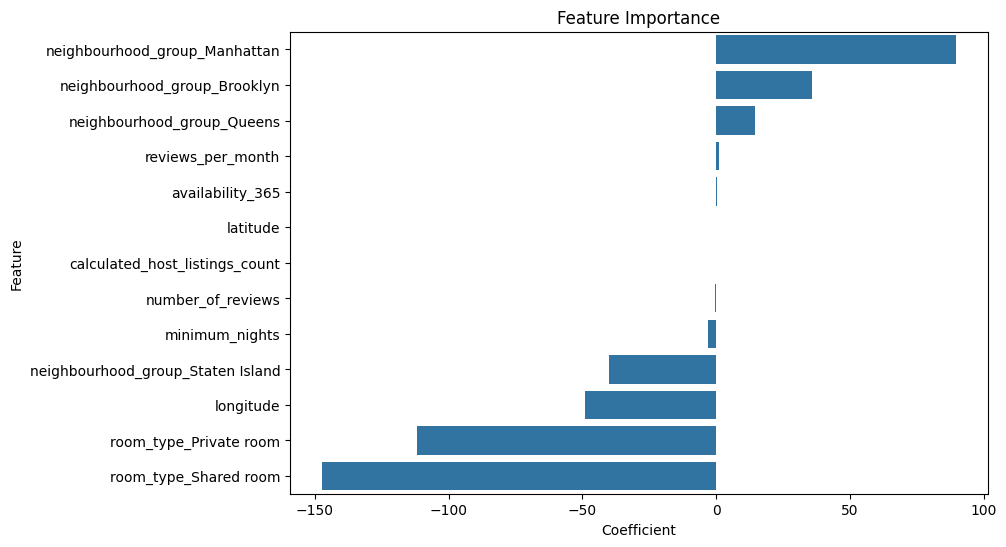

In [221]:
# create a df and their corresponding coeffiecents

coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)

# sort them by their impact
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
print(coefficients)

print("----Feature Coefficents---")
print(coefficients.to_string(index = False))

# visualize
plt.figure(figsize=(9,6))
sns.barplot(x='Coefficient', y='Feature', data=coefficients)
plt.title('Feature Importance')
plt.show()